# 🧠 Parkinson's Disease Detection using DaTscan SPECT Images
### Subject-Level Multiple-Instance Learning (MIL) with Gated Attention
**Benchmark Dataset:** NTUA Parkinson Dataset (*Tagaris et al., 2018*)

---

## 📌 Overview
This interactive notebook provides an end-to-end framework for detecting **Parkinson's Disease (PD)** vs. **Non-PD Controls** (Essential Tremor, SWEDD, Dystonia) using **DaTscan SPECT** (Dopamine Transporter Single-Photon Emission Computed Tomography) images.

### Key Highlights:
1. **Subject-Level Multiple-Instance Learning (MIL):** Accommodates variable slice counts across patients without data duplication or leakage.
2. **Gated Attention Mechanism:** Learns to assign higher attention weights to axial slices showing striatal dopamine binding.
3. **Zero-Leakage Subject-Stratified Split:** Evaluated on completely unseen test patients.

In [1]:
# 1. Environment Setup & Reproducibility Seed
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing on Device: {device}")

Executing on Device: cpu


## 📂 2. Data Loading & Curation
Load subjects from the NTUA dataset, filter uninformative background slices, and prepare subject bags.

In [2]:
def is_valid_slice(img_path, min_mean_threshold=3.0):
    """Filter out pitch-black background / empty padding slices."""
    try:
        im = Image.open(img_path).convert('L')
        arr = np.array(im)
        return arr.mean() >= min_mean_threshold
    except Exception:
        return False

def load_subject_dataset(base_dir):
    pd_dir = os.path.join(base_dir, 'PD Patients')
    npd_dir = os.path.join(base_dir, 'Non PD Patients')
    excluded_subjects = {'Subject20', 'Subject22', 'Subject24', 'Subject58'}
    subjects_data = []
    
    # PD Patients (Class 1)
    for s in os.listdir(pd_dir):
        if not s.startswith('Subject') or s in excluded_subjects:
            continue
        dat_dir = os.path.join(pd_dir, s, '0.DAT')
        if not os.path.exists(dat_dir):
            continue
        valid_images = []
        for root, _, files in os.walk(dat_dir):
            for f in sorted(files):
                if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                    fp = os.path.join(root, f)
                    if is_valid_slice(fp):
                        valid_images.append(fp)
        if len(valid_images) > 0:
            subjects_data.append({
                'subject_id': s,
                'label': 1,
                'label_name': 'PD',
                'image_paths': valid_images
            })
            
    # Non-PD Controls (Class 0)
    for s in os.listdir(npd_dir):
        if not s.startswith('Subject') or s in excluded_subjects:
            continue
        dat_dir = os.path.join(npd_dir, s, '0.DAT')
        if not os.path.exists(dat_dir):
            continue
        valid_images = []
        for root, _, files in os.walk(dat_dir):
            for f in sorted(files):
                if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                    fp = os.path.join(root, f)
                    if is_valid_slice(fp):
                        valid_images.append(fp)
        if len(valid_images) > 0:
            subjects_data.append({
                'subject_id': s,
                'label': 0,
                'label_name': 'Non-PD',
                'image_paths': valid_images
            })
    return subjects_data

base_dir = r'ntua-parkinson-dataset-master/ntua-parkinson-dataset-master'
subjects = load_subject_dataset(base_dir)
print(f"Total Subjects Loaded: {len(subjects)} (PD: {sum(s['label']==1 for s in subjects)}, Non-PD: {sum(s['label']==0 for s in subjects)})")

Total Subjects Loaded: 63 (PD: 46, Non-PD: 17)


## 🔀 3. Subject-Stratified Train/Val/Test Split
Ensure zero patient leakage between train and test sets.

In [3]:
labels = [s['label'] for s in subjects]
train_subs, temp_subs = train_test_split(subjects, test_size=0.30, stratify=labels, random_state=42)
temp_labels = [s['label'] for s in temp_subs]
val_subs, test_subs = train_test_split(temp_subs, test_size=0.50, stratify=temp_labels, random_state=42)

print(f"Train Subjects: {len(train_subs)} (PD: {sum(s['label'] for s in train_subs)}, Non-PD: {len(train_subs)-sum(s['label'] for s in train_subs)})")
print(f"Val Subjects:   {len(val_subs)} (PD: {sum(s['label'] for s in val_subs)}, Non-PD: {len(val_subs)-sum(s['label'] for s in val_subs)})")
print(f"Test Subjects:  {len(test_subs)} (PD: {sum(s['label'] for s in test_subs)}, Non-PD: {len(test_subs)-sum(s['label'] for s in test_subs)})")

Train Subjects: 44 (PD: 32, Non-PD: 12)
Val Subjects:   9 (PD: 7, Non-PD: 2)
Test Subjects:  10 (PD: 7, Non-PD: 3)


## 🏗️ 4. Dataset Class & PyTorch Attention-MIL Architecture

In [4]:
class SubjectDaTDataset(Dataset):
    def __init__(self, subject_list, transform=None, max_slices_per_bag=32):
        self.subject_list = subject_list
        self.transform = transform
        self.max_slices_per_bag = max_slices_per_bag

    def __len__(self):
        return len(self.subject_list)

    def __getitem__(self, idx):
        item = self.subject_list[idx]
        image_paths = item['image_paths']
        label = torch.tensor(item['label'], dtype=torch.float32)
        subject_id = item['subject_id']
        
        if len(image_paths) > self.max_slices_per_bag:
            step = len(image_paths) // self.max_slices_per_bag
            selected_paths = image_paths[::step][:self.max_slices_per_bag]
        else:
            selected_paths = image_paths

        tensors = []
        for p in selected_paths:
            im = Image.open(p).convert('RGB')
            im_t = self.transform(im) if self.transform else transforms.ToTensor()(im)
            tensors.append(im_t)
            
        bag_tensor = torch.stack(tensors)
        return bag_tensor, label, subject_id

def collate_mil_bag(batch):
    bag_tensor, label, subject_id = batch[0]
    return bag_tensor, label, subject_id

class AttentionMILNet(nn.Module):
    def __init__(self, feature_dim=512, attention_dim=128, dropout_rate=0.3):
        super(AttentionMILNet, self).__init__()
        weights = models.ResNet18_Weights.DEFAULT
        resnet = models.resnet18(weights=weights)
        self.feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
        
        self.attention_V = nn.Sequential(nn.Linear(feature_dim, attention_dim), nn.Tanh())
        self.attention_U = nn.Sequential(nn.Linear(feature_dim, attention_dim), nn.Sigmoid())
        self.attention_weights = nn.Linear(attention_dim, 1)
        
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(feature_dim, 64),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(64, 1)
        )

    def forward(self, bag):
        features = self.feature_extractor(bag)
        features = features.view(features.size(0), -1)
        
        A_V = self.attention_V(features)
        A_U = self.attention_U(features)
        A = self.attention_weights(A_V * A_U)
        A = torch.transpose(A, 1, 0)
        A = F.softmax(A, dim=1)
        
        subject_embedding = torch.mm(A, features)
        logits = self.classifier(subject_embedding)
        return logits.squeeze(0), A.squeeze(0)

## 🚀 5. Load Best Model Checkpoint & Evaluate Test Cohort

In [5]:
eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = SubjectDaTDataset(test_subs, transform=eval_transforms)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_mil_bag)

model = AttentionMILNet().to(device)
checkpoint_path = 'best_parkinsons_dat_model.pth'
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded trained checkpoint from Epoch {checkpoint['epoch']}!")
else:
    print("Checkpoint file not found; please train the model first using train.py.")

model.eval()
all_preds, all_probs, all_labels = [], [], []
criterion = nn.BCEWithLogitsLoss()
total_loss = 0.0

with torch.no_grad():
    for bag_tensor, label, sub_id in test_loader:
        bag_tensor = bag_tensor.to(device)
        label = label.to(device)
        logits, _ = model(bag_tensor)
        loss = criterion(logits.view(-1), label.view(-1))
        total_loss += loss.item()
        prob = torch.sigmoid(logits).item()
        pred = 1 if prob >= 0.5 else 0
        all_probs.append(prob)
        all_preds.append(pred)
        all_labels.append(int(label.item()))

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, zero_division=0)
rec = recall_score(all_labels, all_preds, zero_division=0)
f1 = f1_score(all_labels, all_preds, zero_division=0)
roc = roc_auc_score(all_labels, all_probs)

print('=' * 55)
print('📊 SUBJECT-LEVEL TEST SET EVALUATION')
print('=' * 55)
print(f"Accuracy:               {acc * 100:.2f}%")
print(f"Precision (PD):         {prec:.4f}")
print(f"Recall / Sensitivity:   {rec:.4f}")
print(f"Binary F1-Score:        {f1:.4f}")
print(f"ROC-AUC Score:          {roc:.4f}")
print('\nDetailed Classification Report:')
print(classification_report(all_labels, all_preds, target_names=['Non-PD Control', 'Parkinson\'s Disease']))

Loaded trained checkpoint from Epoch 23!
📊 SUBJECT-LEVEL TEST SET EVALUATION
Accuracy:               70.00%
Precision (PD):         0.7000
Recall / Sensitivity:   1.0000
Binary F1-Score:        0.8235
ROC-AUC Score:          0.5714

Detailed Classification Report:
                     precision    recall  f1-score   support

     Non-PD Control       0.00      0.00      0.00         3
Parkinson's Disease       0.70      1.00      0.82         7

           accuracy                           0.70        10
          macro avg       0.35      0.50      0.41        10
       weighted avg       0.49      0.70      0.58        10



c:\Users\divya\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\divya\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\divya\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 📈 6. Visualization: Confusion Matrix & ROC Curve

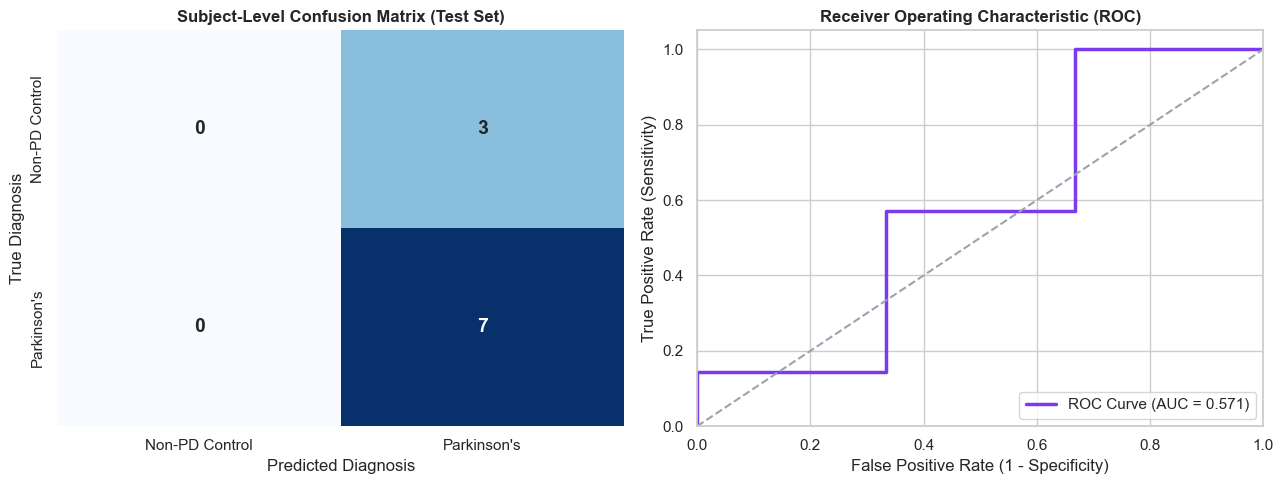

In [6]:
sns.set_theme(style='whitegrid', palette='muted')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# 1. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=['Non-PD Control', 'Parkinson\'s'],
            yticklabels=['Non-PD Control', 'Parkinson\'s'],
            annot_kws={'size': 14, 'fontweight': 'bold'})
ax1.set_title('Subject-Level Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted Diagnosis')
ax1.set_ylabel('True Diagnosis')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
ax2.plot(fpr, tpr, color='#7C3AED', lw=2.5, label=f'ROC Curve (AUC = {roc:.3f})')
ax2.plot([0, 1], [0, 1], color='#9CA3AF', lw=1.5, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate (1 - Specificity)')
ax2.set_ylabel('True Positive Rate (Sensitivity)')
ax2.set_title('Receiver Operating Characteristic (ROC)', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()